<a href="https://colab.research.google.com/github/kelawady/Acoustic_Emissions/blob/main/Filter_2Kto60K_and_Split_AE_into_Intervals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount the drive

In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# Change directory to current path
%cd /content/drive/My\ Drive/$FOLDERNAME/
!pwd
!ls

Mounted at /content/drive
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
 AE_detection_results
 before_after_2bpf.png
 before_after_8KhzNpotch.png
 before_after_hpf.png
 hw1_prob2a.png
 P36_filt_20k_60K_segments
 P36_filt_2k_60K_segments
 P36_filtered_waveform_30-50_kHz.wav
 P36_filtered_waveform_32-46_kHz.wav
 P36_raw_segments
 P36_raw_waveform.wav
'Pillar 36_10um.DTA'
'Pillar 36_10um_Waveform20240721-194953-051.wfs'
 raw_signal_histogram.png
 raw_signal.png
 raw_signal_segments.png
 raw_signal_spectrogram.png


### Load the raw waveform and normalize it

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from numpy.fft import rfft, rfftfreq

# ---- user params ----
wav_path = "P36_raw_waveform.wav"
# ---------------------

# Load WAV (fs is typically 44.1 kHz or 48 kHz; read from file)
fs, x = wavfile.read(wav_path)

# Signal properties
print(f"Sample rate (fs): {fs:,d} Hz")
print(f"Number of samples: {len(x):,d}")
print(f"Duration: {len(x) / fs:,.2f} seconds, {len(x) / fs / 60:,.2f} minutes")
print(f"Shape of signal x: {x.shape}")
print(f"Min value: {np.min(x)}")
print(f"Max value: {np.max(x)}")
print(f"Data type: {x.dtype}")
print(f"Mean value: {np.mean(x)}")
print(f"Standard deviation: {np.std(x)}")

# Normalize the signal

# Convert to float for processing
x = x.astype(np.float64)

# Normalize to [-1, 1] by max absolute value
max_abs = np.max(np.abs(x))
if max_abs > 0:
    x = x / max_abs

duration = len(x) / fs
N = len(x)
t = np.arange(N) / fs

Sample rate (fs): 2,000,000 Hz
Number of samples: 275,770,644
Duration: 137.89 seconds, 2.30 minutes
Shape of signal x: (275770644,)
Min value: -277
Max value: 224
Data type: int16
Mean value: -0.4951621790461497
Standard deviation: 13.326078339880402


### Filter using a band pass filter from 2KHz to 60 KHz

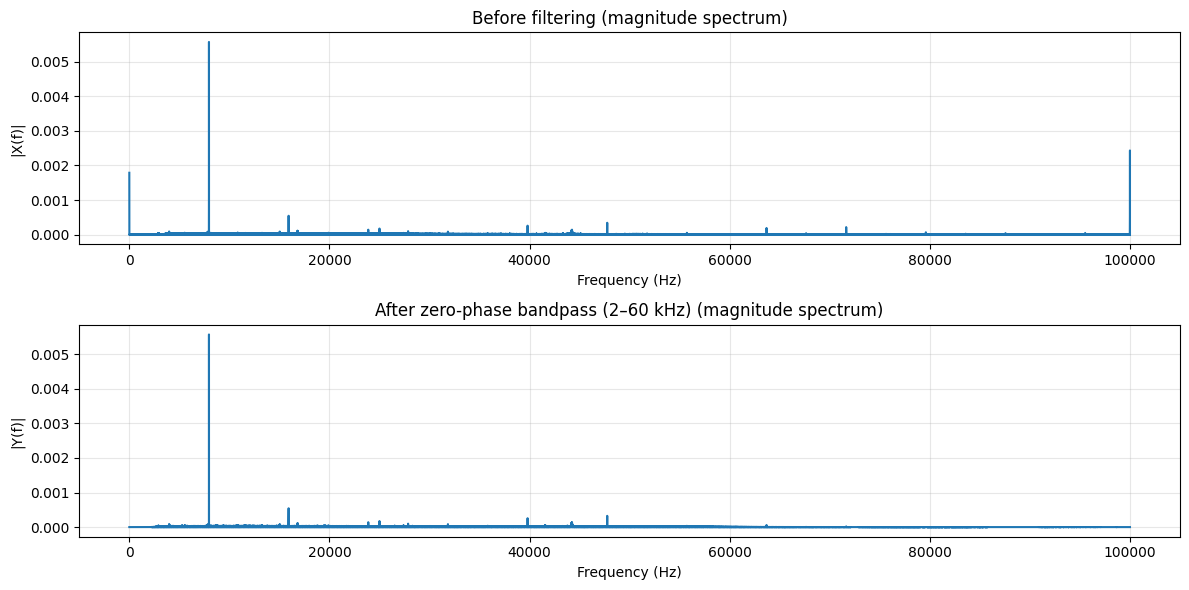

In [3]:
from scipy import signal

# ------------------------
# Parameters
# ------------------------
fs = 2_000_000.0          # 2 MHz sampling rate
f_lo = 2_000.0           # 20 kHz
f_hi = 60_000.0           # 60 kHz
order = 6                 # Butterworth order (adjust if needed)

# ------------------------
# Design zero-phase bandpass (use SOS for numerical stability)
# ------------------------
sos = signal.butter(
    N=order,
    Wn=[f_lo, f_hi],
    btype="bandpass",
    fs=fs,
    output="sos"
)

# ------------------------
# Apply filter (zero-phase, offline)
# ------------------------
# x is your 1D numpy array signal
# Example: x = np.asarray(x, dtype=float)
y = signal.sosfiltfilt(sos, x)

# ------------------------
# Magnitude spectra (0 to 100 kHz)
# ------------------------
def mag_spectrum(sig, fs):
    sig = np.asarray(sig)
    N = sig.size
    X = np.fft.rfft(sig)
    f = np.fft.rfftfreq(N, d=1/fs)
    mag = np.abs(X) / N
    return f, mag

f_x, mag_x = mag_spectrum(x, fs)
f_y, mag_y = mag_spectrum(y, fs)

fmax_plot = 100_000.0
mask_x = f_x <= fmax_plot
mask_y = f_y <= fmax_plot

# ------------------------
# Plot (2x1: before / after)
# ------------------------
plt.figure(figsize=(12, 6))

ax1 = plt.subplot(2, 1, 1)
ax1.plot(f_x[mask_x], mag_x[mask_x])
ax1.set_title("Before filtering (magnitude spectrum)")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("|X(f)|")
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 1, 2)
ax2.plot(f_y[mask_y], mag_y[mask_y])
ax2.set_title("After zero-phase bandpass (2–60 kHz) (magnitude spectrum)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("|Y(f)|")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Split and store the filtered signal into a new directory

In [5]:
from pathlib import Path

def segment_signal(x, fs, w, overlap_percent, out_dir):
    """
    Segment a 1-D signal into overlapping windows, zero-pad the final window,
    and save each segment to disk.

    Parameters
    ----------
    x : np.ndarray
        1-D input signal
    fs : float
        Sampling frequency (Hz)
    w : float
        Window length (seconds)
    overlap_percent : float
        Overlap percentage [0, 100)
    out_dir : str or Path
        Directory name (created under current working directory if it doesn't exist)

    Returns
    -------
    segments : np.ndarray
        Shape (n_windows, win_len). All windows same length.
    starts : np.ndarray
        Start sample index for each segment (0-based).
    ends_inclusive : np.ndarray
        End sample index (inclusive) for each segment (0-based).
    out_path : Path
        Path to the directory where segments were saved.
    """

    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError("Input signal must be 1-D.")

    if not (0 <= overlap_percent < 100):
        raise ValueError("overlap_percent must be in [0, 100).")

    win_len = int(round(w * fs))
    if win_len <= 0:
        raise ValueError("Window length must be positive.")

    hop = int(round(win_len * (1 - overlap_percent / 100.0)))
    if hop <= 0:
        raise ValueError("Overlap too large; hop size becomes zero.")

    N = len(x)
    if N == 0:
        raise ValueError("Input signal is empty.")

    # Number of windows using ceil so we cover the tail with zero-padding
    # n_windows = ceil((N - win_len)/hop) + 1, but handle N < win_len too
    if N <= win_len:
        n_windows = 1
    else:
        n_windows = int(np.ceil((N - win_len) / hop)) + 1

    # Pad x so that the last window fits exactly
    total_len_needed = (n_windows - 1) * hop + win_len
    pad_len = max(0, total_len_needed - N)
    if pad_len > 0:
        x_pad = np.pad(x, (0, pad_len), mode="constant", constant_values=0)
    else:
        x_pad = x

    # Stride trick to create (n_windows, win_len) view
    shape = (n_windows, win_len)
    strides = (x_pad.strides[0] * hop, x_pad.strides[0])
    segments = np.lib.stride_tricks.as_strided(x_pad, shape=shape, strides=strides).copy()

    # Prepare output directory under current working directory
    out_path = Path.cwd() / str(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Start/end indices (end is inclusive, in original sample index space)
    starts = np.arange(n_windows, dtype=np.int64) * hop
    ends_inclusive = starts + win_len - 1

    # Save each segment
    for i in range(n_windows):
        start = int(starts[i])
        end_inc = int(ends_inclusive[i])
        fname = f"P36_filt_{start}_{end_inc}.npy"
        np.save(out_path / fname, segments[i])

    return segments, starts, ends_inclusive, out_path



In [6]:
!pwd

/content/drive/MyDrive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE


In [7]:
y_segs, starts, ends, folder = segment_signal(
    y,
    fs=2_000_000,
    w=1.0,              # 1,000 ms windows
    overlap_percent=0,
    out_dir="P36_filt_2k_60K_segments"
)

print(y_segs.shape)
print("Saved to:", folder)
print("First file:", f"P36_filt_{starts[0]}_{ends[0]}.npy")

(138, 2000000)
Saved to: /content/drive/MyDrive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE/P36_filt_2k_60K_segments
First file: P36_filt_0_1999999.npy


### For reference print the peaks of the filtered magnitude spectrum

In [8]:
def find_top_n_spectrum_peaks(freqs, mag, n=5, min_freq=None, max_freq=None):
    """
    Find the top n magnitude values in a spectrum.

    Prints:
      - Frequency
      - Magnitude
      - Relative magnitude (linear ratio to largest component)
      - Relative magnitude (dB)

    Returns
    -------
    top_freqs : np.ndarray
    top_mags : np.ndarray
    """

    freqs = np.asarray(freqs)
    mag = np.asarray(mag)

    # Optional frequency masking
    mask = np.ones_like(freqs, dtype=bool)
    if min_freq is not None:
        mask &= freqs >= min_freq
    if max_freq is not None:
        mask &= freqs <= max_freq

    freqs_masked = freqs[mask]
    mag_masked = mag[mask]

    if len(mag_masked) == 0:
        raise ValueError("No frequencies remain after applying mask.")

    # Largest component in entire masked spectrum
    global_max = np.max(mag_masked)

    if n > len(mag_masked):
        n = len(mag_masked)

    # Indices of largest n values
    idx = np.argpartition(mag_masked, -n)[-n:]
    idx_sorted = idx[np.argsort(mag_masked[idx])[::-1]]

    top_freqs = freqs_masked[idx_sorted]
    top_mags = mag_masked[idx_sorted]

    print(f"\nTop {n} spectral peaks (relative to largest component):")
    for i in range(n):
        ratio = top_mags[i] / global_max
        ratio_db = 20 * np.log10(ratio + 1e-20)  # avoid log(0)
        print(
            f"{i+1}: "
            f"Frequency = {top_freqs[i]:.2f} Hz, "
            f"Magnitude = {top_mags[i]:.6g}, "
            f"Relative = {ratio:.4f} ({ratio_db:.2f} dB)"
        )

    return top_freqs, top_mags

In [10]:
top_freqs, top_mags = find_top_n_spectrum_peaks(
    f_y,
    mag_y,
    n=40,
    min_freq=0,
    max_freq=100_000
)


Top 40 spectral peaks (relative to largest component):
1: Frequency = 7960.17 Hz, Magnitude = 0.00556898, Relative = 1.0000 (0.00 dB)
2: Frequency = 7960.17 Hz, Magnitude = 0.00117333, Relative = 0.2107 (-13.53 dB)
3: Frequency = 7960.18 Hz, Magnitude = 0.000847492, Relative = 0.1522 (-16.35 dB)
4: Frequency = 15920.35 Hz, Magnitude = 0.000544232, Relative = 0.0977 (-20.20 dB)
5: Frequency = 7960.16 Hz, Magnitude = 0.000516242, Relative = 0.0927 (-20.66 dB)
6: Frequency = 7960.19 Hz, Magnitude = 0.000500991, Relative = 0.0900 (-20.92 dB)
7: Frequency = 47761.03 Hz, Magnitude = 0.000325128, Relative = 0.0584 (-24.67 dB)
8: Frequency = 7960.15 Hz, Magnitude = 0.000289373, Relative = 0.0520 (-25.69 dB)
9: Frequency = 7960.19 Hz, Magnitude = 0.00028862, Relative = 0.0518 (-25.71 dB)
10: Frequency = 39800.86 Hz, Magnitude = 0.000256732, Relative = 0.0461 (-26.73 dB)
11: Frequency = 7960.20 Hz, Magnitude = 0.000236597, Relative = 0.0425 (-27.44 dB)
12: Frequency = 7960.14 Hz, Magnitude = 0.

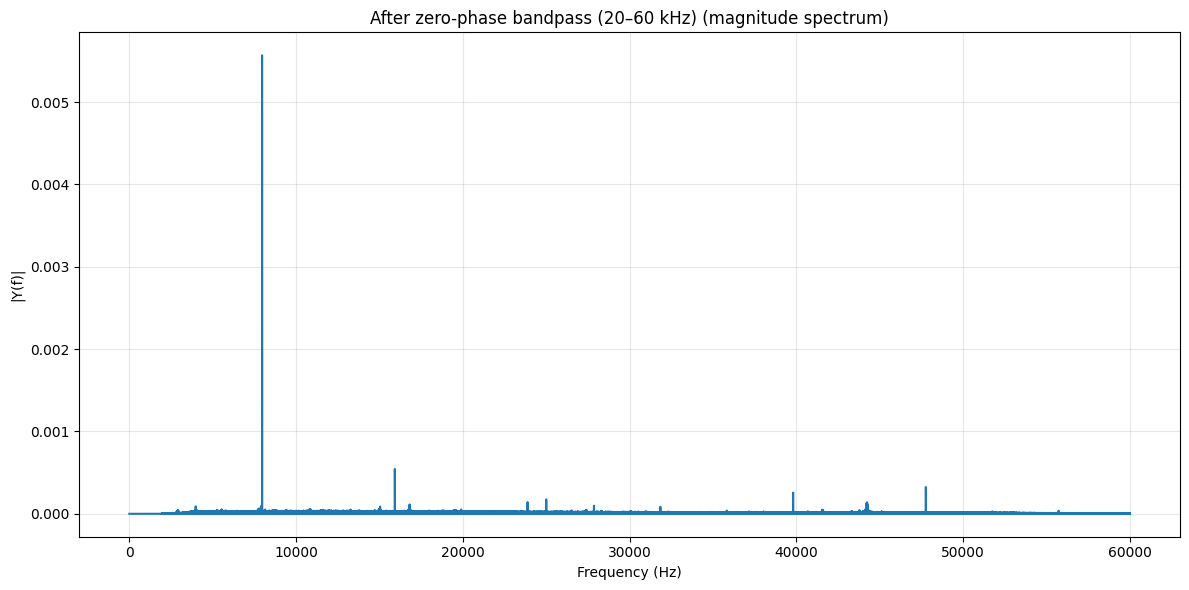

In [6]:
fmin_plot = 0_000.0
fmax_plot = 60_000.0

mask_y = (f_y >= fmin_plot) & (f_y <= fmax_plot)

plt.figure(figsize=(12, 6))
plt.plot(f_y[mask_y], mag_y[mask_y])
plt.title("After zero-phase bandpass (20–60 kHz) (magnitude spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|Y(f)|")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Save the filtered waverform

In [7]:
!pwd

/content/drive/MyDrive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE


In [8]:
np.save("P36_filt_2K_60K.npy", y)